In [1]:
# Step 5: Critical Thinking, Explainability & Fairness
# Cell 1 — Environment Check

import os
import sys
import numpy as np
import pandas as pd
import joblib
import sklearn

print("Step 5 environment check")
print("-" * 40)
print("Python version:", sys.version.split()[0])
print("Working directory:", os.getcwd())
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Scikit-learn version:", sklearn.__version__)

# Check SHAP availability
try:
    import shap
    print("SHAP version:", shap.__version__)
    shap_available = True
except ImportError:
    print("SHAP: NOT INSTALLED")
    shap_available = False

print("-" * 40)
print("Environment check completed.")

Step 5 environment check
----------------------------------------
Python version: 3.11.16
Working directory: C:\Users\Rufus1503
NumPy version: 2.4.6
Pandas version: 3.0.5
Scikit-learn version: 1.9.0


C:\Users\Rufus1503\.conda\envs\capstone\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.51.0
----------------------------------------
Environment check completed.


In [3]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Step 5 — Cell 3
# Load the final Random Forest and Step 4 test data

import joblib
import os

# Load final model
rf_model = joblib.load("models/random_forest.joblib")

# Load saved test data
X_test_selected = joblib.load("artifacts/X_test_selected.joblib")
y_test = joblib.load("artifacts/y_test.joblib")

# Load selected feature names
selected_features = joblib.load("artifacts/selected_features.joblib")

print("Step 4 artefacts loaded successfully.")
print("-" * 40)
print("Model:", type(rf_model).__name__)
print("Test features shape:", X_test_selected.shape)
print("Test target shape:", y_test.shape)
print("Number of selected features:", len(selected_features))
print("First 10 features:")
print(selected_features[:10])

Step 4 artefacts loaded successfully.
----------------------------------------
Model: RandomForestClassifier
Test features shape: (885, 49)
Test target shape: (885,)
Number of selected features: 49
First 10 features:
['cat__Tuition fees up to date_1', 'cat__Tuition fees up to date_0', 'num__Financial_Risk_Flag', 'num__Age at enrollment', 'num__Previous qualification (grade)', 'cat__Scholarship holder_1', 'cat__Gender_1', 'cat__Age_Group_Under 20', 'cat__Debtor_1', 'cat__Debtor_0']


In [3]:
# Step 5 — Cell 4
# Verify final model predictions

y_pred = rf_model.predict(X_test_selected)
y_prob = rf_model.predict_proba(X_test_selected)[:, 1]

print("Final model prediction check")
print("-" * 40)
print("Predictions generated:", len(y_pred))
print("Probability predictions generated:", len(y_prob))
print("Predicted dropout students:", int(y_pred.sum()))
print("Actual dropout students:", int(np.sum(y_test)))
print("Minimum predicted probability:", round(float(y_prob.min()), 4))
print("Maximum predicted probability:", round(float(y_prob.max()), 4))

Final model prediction check
----------------------------------------
Predictions generated: 885
Probability predictions generated: 885
Predicted dropout students: 327
Actual dropout students: 284
Minimum predicted probability: 0.0739
Maximum predicted probability: 0.9918


In [4]:
# Step 5 — Cell 5
# Create SHAP explainer

import shap

print("Creating SHAP TreeExplainer...")
explainer = shap.TreeExplainer(rf_model)

print("SHAP TreeExplainer created successfully.")

Creating SHAP TreeExplainer...
SHAP TreeExplainer created successfully.


In [5]:
# Step 5 — Cell 6
# Calculate SHAP values for the test set

print("Calculating SHAP values...")

shap_values = explainer.shap_values(X_test_selected)

print("SHAP values calculated successfully.")
print("-" * 40)
print("SHAP values type:", type(shap_values))

Calculating SHAP values...
SHAP values calculated successfully.
----------------------------------------
SHAP values type: <class 'numpy.ndarray'>


In [7]:
# Step 5 — Cell 7
# Verify SHAP value dimensions for binary classification

print("SHAP structure verification")
print("-" * 40)
print("SHAP values shape:", shap_values.shape)
print("Test data shape:", X_test_selected.shape)
print("Number of features:", len(selected_features))

print("-" * 40)

if shap_values.shape[:2] == X_test_selected.shape and shap_values.shape[2] == 2:
    print("SHAP dimensions verified.")
    print("Class 0: Non-dropout")
    print("Class 1: Dropout")
else:
    print("WARNING: Unexpected SHAP dimensions.")

SHAP structure verification
----------------------------------------
SHAP values shape: (885, 49, 2)
Test data shape: (885, 49)
Number of features: 49
----------------------------------------
SHAP dimensions verified.
Class 0: Non-dropout
Class 1: Dropout


In [8]:
# Step 5 — Cell 8
# Extract SHAP values for the Dropout class

shap_dropout = shap_values[:, :, 1]

print("Dropout-class SHAP values extracted successfully.")
print("-" * 40)
print("Dropout SHAP shape:", shap_dropout.shape)
print("Expected shape:", X_test_selected.shape)

Dropout-class SHAP values extracted successfully.
----------------------------------------
Dropout SHAP shape: (885, 49)
Expected shape: (885, 49)


In [9]:
# Step 5 — Cell 9
# Global SHAP feature importance

shap_importance = pd.DataFrame({
    "Feature": selected_features,
    "Mean_Absolute_SHAP": np.mean(np.abs(shap_dropout), axis=0)
})

shap_importance = shap_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

print("Global SHAP feature importance calculated.")
print("-" * 40)
print(shap_importance.head(15).to_string(index=False))

Global SHAP feature importance calculated.
----------------------------------------
                            Feature  Mean_Absolute_SHAP
             num__Age at enrollment            0.048256
     cat__Tuition fees up to date_0            0.040262
           num__Financial_Risk_Flag            0.038492
     cat__Tuition fees up to date_1            0.036548
          cat__Scholarship holder_1            0.035042
          cat__Scholarship holder_0            0.034848
                      cat__Gender_1            0.024482
                      cat__Gender_0            0.024276
            cat__Application mode_1            0.023858
                   cat__Course_9500            0.018885
            cat__Age_Group_Under 20            0.011424
               num__Admission grade            0.011193
                 cat__Age_Group_30+            0.008432
num__Previous qualification (grade)            0.008245
                      cat__Debtor_1            0.007808


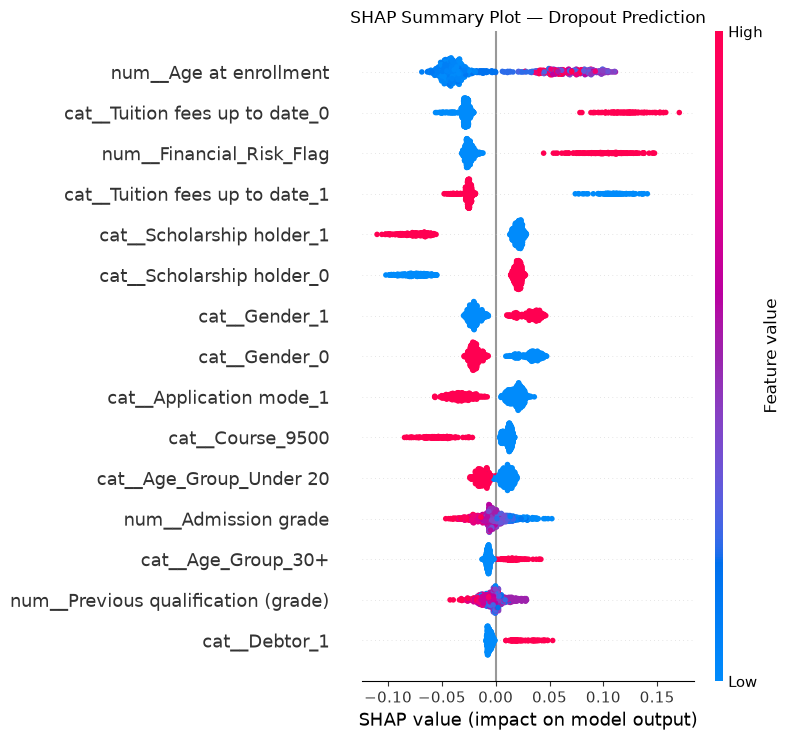

In [10]:
# Step 5 — Cell 10
# SHAP summary plot for Dropout predictions

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_dropout,
    X_test_selected,
    feature_names=selected_features,
    max_display=15,
    show=False
)

plt.title("SHAP Summary Plot — Dropout Prediction")
plt.tight_layout()
plt.show()

In [11]:
# Step 5 — Cell 11
# Save global SHAP feature importance

os.makedirs("artifacts", exist_ok=True)

shap_importance.to_csv(
    "artifacts/shap_feature_importance.csv",
    index=False
)

print("SHAP feature importance saved successfully.")
print("Saved file: artifacts/shap_feature_importance.csv")

SHAP feature importance saved successfully.
Saved file: artifacts/shap_feature_importance.csv


In [12]:
# Step 5 — Cell 12
# Identify gender-related features

gender_features = [
    feature for feature in selected_features
    if "Gender" in feature
]

print("Gender-related features found:")
print("-" * 40)

for feature in gender_features:
    print(feature)

print("-" * 40)
print("Number of gender features:", len(gender_features))

Gender-related features found:
----------------------------------------
cat__Gender_1
cat__Gender_0
----------------------------------------
Number of gender features: 2


In [13]:
# Step 5 — Cell 13
# Check gender group representation in the test set

gender_1 = X_test_selected[:, selected_features.index("cat__Gender_1")]
gender_0 = X_test_selected[:, selected_features.index("cat__Gender_0")]

print("Gender group representation")
print("-" * 40)
print("Gender_1 = 1:", int(np.sum(gender_1)))
print("Gender_0 = 1:", int(np.sum(gender_0)))
print("Total test students:", len(X_test_selected))
print("-" * 40)

if np.all((gender_1 + gender_0) == 1):
    print("Gender encoding verified: each student belongs to one group.")
else:
    print("WARNING: Gender encoding requires further inspection.")

Gender group representation
----------------------------------------
Gender_1 = 1: 321
Gender_0 = 1: 564
Total test students: 885
----------------------------------------
Gender encoding verified: each student belongs to one group.


In [14]:
# Step 5 — Cell 14
# Gender fairness outcome comparison

from sklearn.metrics import confusion_matrix

gender_groups = {
    "Gender_1": gender_1 == 1,
    "Gender_0": gender_0 == 1
}

gender_results = []

for group_name, mask in gender_groups.items():
    y_true_group = np.asarray(y_test)[mask]
    y_pred_group = np.asarray(y_pred)[mask]

    tn, fp, fn, tp = confusion_matrix(
        y_true_group,
        y_pred_group,
        labels=[0, 1]
    ).ravel()

    actual_dropout_rate = np.mean(y_true_group)
    predicted_dropout_rate = np.mean(y_pred_group)

    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else np.nan

    gender_results.append({
        "Group": group_name,
        "N": int(mask.sum()),
        "Actual_Dropout_Rate": actual_dropout_rate,
        "Predicted_Dropout_Rate": predicted_dropout_rate,
        "Dropout_Recall": recall,
        "Precision": precision,
        "False_Positive_Rate": false_positive_rate
    })

gender_results_df = pd.DataFrame(gender_results)

print("Gender fairness outcome comparison")
print("-" * 40)
print(
    gender_results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

Gender fairness outcome comparison
----------------------------------------
   Group   N  Actual_Dropout_Rate  Predicted_Dropout_Rate  Dropout_Recall  Precision  False_Positive_Rate
Gender_1 321               0.4548                  0.5732          0.7808     0.6196               0.4000
Gender_0 564               0.2447                  0.2535          0.6087     0.5874               0.1385


In [15]:
# Step 5 — Cell 15
# Formal gender fairness metrics

group_1 = gender_results_df[
    gender_results_df["Group"] == "Gender_1"
].iloc[0]

group_0 = gender_results_df[
    gender_results_df["Group"] == "Gender_0"
].iloc[0]

# Selection / predicted-positive rates
selection_rate_1 = group_1["Predicted_Dropout_Rate"]
selection_rate_0 = group_0["Predicted_Dropout_Rate"]

# Demographic Parity Difference
dp_difference = selection_rate_1 - selection_rate_0

# Disparate Impact
disparate_impact = selection_rate_1 / selection_rate_0

# Equal Opportunity Difference
equal_opportunity_difference = (
    group_1["Dropout_Recall"] - group_0["Dropout_Recall"]
)

print("Gender fairness metrics")
print("-" * 40)
print(f"Gender_1 selection rate: {selection_rate_1:.4f}")
print(f"Gender_0 selection rate: {selection_rate_0:.4f}")
print(f"Demographic Parity Difference: {dp_difference:.4f}")
print(f"Disparate Impact: {disparate_impact:.4f}")
print(
    f"Equal Opportunity Difference: "
    f"{equal_opportunity_difference:.4f}"
)

Gender fairness metrics
----------------------------------------
Gender_1 selection rate: 0.5732
Gender_0 selection rate: 0.2535
Demographic Parity Difference: 0.3197
Disparate Impact: 2.2608
Equal Opportunity Difference: 0.1721


In [16]:
# Step 5 — Cell 16
# Save gender fairness audit results

gender_results_df.to_csv(
    "artifacts/gender_fairness_results.csv",
    index=False
)

fairness_metrics = pd.DataFrame({
    "Metric": [
        "Demographic Parity Difference",
        "Disparate Impact",
        "Equal Opportunity Difference"
    ],
    "Value": [
        dp_difference,
        disparate_impact,
        equal_opportunity_difference
    ]
})

fairness_metrics.to_csv(
    "artifacts/gender_fairness_metrics.csv",
    index=False
)

print("Gender fairness audit results saved successfully.")
print("Saved:")
print("- artifacts/gender_fairness_results.csv")
print("- artifacts/gender_fairness_metrics.csv")

Gender fairness audit results saved successfully.
Saved:
- artifacts/gender_fairness_results.csv
- artifacts/gender_fairness_metrics.csv


In [17]:
# Step 5 — Cell 17
# Identify age-group features

age_group_features = [
    feature for feature in selected_features
    if "Age_Group" in feature
]

print("Age-group features found:")
print("-" * 40)

for feature in age_group_features:
    print(feature)

print("-" * 40)
print("Number of age-group features:", len(age_group_features))

Age-group features found:
----------------------------------------
cat__Age_Group_Under 20
cat__Age_Group_30+
----------------------------------------
Number of age-group features: 2


In [18]:
# Step 5 — Cell 18
# Check age-group representation in the test set

age_under20 = X_test_selected[
    :, selected_features.index("cat__Age_Group_Under 20")
]

age_30plus = X_test_selected[
    :, selected_features.index("cat__Age_Group_30+")
]

age_middle = (age_under20 == 0) & (age_30plus == 0)

print("Age-group representation")
print("-" * 40)
print("Under 20:", int(np.sum(age_under20)))
print("30+:", int(np.sum(age_30plus)))
print("Reference/middle group:", int(np.sum(age_middle)))
print("Total test students:", len(X_test_selected))
print("-" * 40)

if np.all(
    ((age_under20 + age_30plus) <= 1)
):
    print("Age-group encoding verified.")
else:
    print("WARNING: Age-group encoding requires further inspection.")

Age-group representation
----------------------------------------
Under 20: 412
30+: 150
Reference/middle group: 323
Total test students: 885
----------------------------------------
Age-group encoding verified.


In [19]:
# Step 5 — Cell 19
# Age-group fairness outcome comparison

age_groups = {
    "Under 20": age_under20 == 1,
    "Middle/reference": age_middle,
    "30+": age_30plus == 1
}

age_results = []

for group_name, mask in age_groups.items():
    y_true_group = np.asarray(y_test)[mask]
    y_pred_group = np.asarray(y_pred)[mask]

    tn, fp, fn, tp = confusion_matrix(
        y_true_group,
        y_pred_group,
        labels=[0, 1]
    ).ravel()

    actual_dropout_rate = np.mean(y_true_group)
    predicted_dropout_rate = np.mean(y_pred_group)

    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else np.nan

    age_results.append({
        "Age_Group": group_name,
        "N": int(mask.sum()),
        "Actual_Dropout_Rate": actual_dropout_rate,
        "Predicted_Dropout_Rate": predicted_dropout_rate,
        "Dropout_Recall": recall,
        "Precision": precision,
        "False_Positive_Rate": false_positive_rate
    })

age_results_df = pd.DataFrame(age_results)

print("Age-group fairness outcome comparison")
print("-" * 40)
print(
    age_results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

Age-group fairness outcome comparison
----------------------------------------
       Age_Group   N  Actual_Dropout_Rate  Predicted_Dropout_Rate  Dropout_Recall  Precision  False_Positive_Rate
        Under 20 412               0.2039                  0.1432          0.3810     0.5424               0.0823
Middle/reference 323               0.3498                  0.4458          0.7434     0.5833               0.2857
             30+ 150               0.5800                  0.8267          0.9425     0.6613               0.6667


In [20]:
# Step 5 — Cell 20
# Formal age-group fairness metrics

reference = age_results_df[
    age_results_df["Age_Group"] == "Middle/reference"
].iloc[0]

comparison_groups = age_results_df[
    age_results_df["Age_Group"] != "Middle/reference"
]

age_fairness_metrics = []

for _, group in comparison_groups.iterrows():

    selection_rate = group["Predicted_Dropout_Rate"]
    reference_selection_rate = reference["Predicted_Dropout_Rate"]

    recall = group["Dropout_Recall"]
    reference_recall = reference["Dropout_Recall"]

    dp_difference = selection_rate - reference_selection_rate

    disparate_impact = (
        selection_rate / reference_selection_rate
        if reference_selection_rate > 0
        else np.nan
    )

    equal_opportunity_difference = recall - reference_recall

    age_fairness_metrics.append({
        "Comparison_Group": group["Age_Group"],
        "Reference_Group": "Middle/reference",
        "Demographic_Parity_Difference": dp_difference,
        "Disparate_Impact": disparate_impact,
        "Equal_Opportunity_Difference": equal_opportunity_difference
    })

age_fairness_metrics_df = pd.DataFrame(age_fairness_metrics)

print("Age-group fairness metrics")
print("-" * 40)
print(
    age_fairness_metrics_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

Age-group fairness metrics
----------------------------------------
Comparison_Group  Reference_Group  Demographic_Parity_Difference  Disparate_Impact  Equal_Opportunity_Difference
        Under 20 Middle/reference                        -0.3026            0.3212                       -0.3624
             30+ Middle/reference                         0.3808            1.8543                        0.1992


In [21]:
# Step 5 — Cell 21
# Save age-group fairness audit results

age_results_df.to_csv(
    "artifacts/age_group_fairness_results.csv",
    index=False
)

age_fairness_metrics_df.to_csv(
    "artifacts/age_group_fairness_metrics.csv",
    index=False
)

print("Age-group fairness audit results saved successfully.")
print("Saved:")
print("- artifacts/age_group_fairness_results.csv")
print("- artifacts/age_group_fairness_metrics.csv")

Age-group fairness audit results saved successfully.
Saved:
- artifacts/age_group_fairness_results.csv
- artifacts/age_group_fairness_metrics.csv


In [22]:
# Step 5 — Cell 22
# Document limitations and mitigation considerations

step5_limitations = {
    "Class imbalance": {
        "Issue": "The dropout class is not perfectly balanced in the test set.",
        "Evidence": "284 of 885 test students were actual dropouts (32.1%).",
        "Consideration": "Accuracy alone may not adequately represent performance, so Recall, Precision, F1-score and ROC-AUC were also evaluated.",
        "Potential mitigation": "Consider class weighting, resampling, or threshold optimisation if future deployment requires improved minority-class detection."
    },

    "Fairness disparities": {
        "Issue": "Prediction rates and performance differ across gender and age groups.",
        "Evidence": "Gender and age-group fairness metrics show measurable differences in selection rates, recall and false-positive rates.",
        "Consideration": "Observed disparities should be interpreted alongside differences in the underlying dropout rates.",
        "Potential mitigation": "Monitor subgroup performance regularly and consider group-aware threshold analysis, reweighting, or other fairness-aware modelling approaches where appropriate."
    },

    "Potential data leakage": {
        "Issue": "Features used for prediction must be available at the time an intervention decision is made.",
        "Evidence": "The project uses financial, demographic, academic and application-related variables.",
        "Consideration": "Future deployment should verify that no post-outcome information is included.",
        "Potential mitigation": "Apply temporal validation and explicitly document feature availability at prediction time."
    },

    "Overfitting": {
        "Issue": "Model performance on unseen data may differ from training or cross-validation performance.",
        "Evidence": "The tuned Random Forest had a cross-validation F1-score of 0.6226 but achieved a lower test F1-score of 0.6439 than the untuned baseline's 0.6481.",
        "Consideration": "Cross-validation results should not automatically be assumed to represent future deployment performance.",
        "Potential mitigation": "Use cross-validation, hold-out testing, regularisation and periodic monitoring on new data."
    },

    "Sensitive features": {
        "Issue": "Gender and age-related variables contribute to model predictions.",
        "Evidence": "Gender appears among the SHAP-ranked features, while Age at enrollment is the strongest SHAP predictor.",
        "Consideration": "Predictive usefulness does not by itself establish that using a sensitive attribute is ethically appropriate.",
        "Potential mitigation": "Compare models with and without sensitive attributes and evaluate the resulting performance/fairness trade-offs before deployment."
    }
}

step5_limitations_df = pd.DataFrame([
    {
        "Area": area,
        "Issue": details["Issue"],
        "Evidence": details["Evidence"],
        "Consideration": details["Consideration"],
        "Potential_Mitigation": details["Potential mitigation"]
    }
    for area, details in step5_limitations.items()
])

print("Step 5 limitations and mitigation considerations")
print("-" * 40)
print(step5_limitations_df[["Area", "Issue"]].to_string(index=False))

Step 5 limitations and mitigation considerations
----------------------------------------
                  Area                                                                                        Issue
       Class imbalance                                 The dropout class is not perfectly balanced in the test set.
  Fairness disparities                        Prediction rates and performance differ across gender and age groups.
Potential data leakage Features used for prediction must be available at the time an intervention decision is made.
           Overfitting   Model performance on unseen data may differ from training or cross-validation performance.
    Sensitive features                            Gender and age-related variables contribute to model predictions.


In [23]:
# Step 5 — Cell 23
# Save limitations and mitigation considerations

step5_limitations_df.to_csv(
    "artifacts/step5_limitations_mitigations.csv",
    index=False
)

print("Step 5 limitations and mitigation table saved successfully.")
print("Saved file: artifacts/step5_limitations_mitigations.csv")

Step 5 limitations and mitigation table saved successfully.
Saved file: artifacts/step5_limitations_mitigations.csv


In [24]:
# Step 5 — Cell 24
# Final verification of Step 5 artefacts

import os

step5_files = [
    "artifacts/shap_feature_importance.csv",
    "artifacts/gender_fairness_results.csv",
    "artifacts/gender_fairness_metrics.csv",
    "artifacts/age_group_fairness_results.csv",
    "artifacts/age_group_fairness_metrics.csv",
    "artifacts/step5_limitations_mitigations.csv"
]

print("STEP 5 FINAL VERIFICATION")
print("-" * 40)

all_files_exist = True

for file_path in step5_files:
    exists = os.path.exists(file_path)
    status = "OK" if exists else "MISSING"
    print(f"{file_path}: {status}")

    if not exists:
        all_files_exist = False

print("-" * 40)

if all_files_exist:
    print("Step 5 coding workflow completed successfully.")
else:
    print("WARNING: One or more Step 5 artefacts are missing.")

STEP 5 FINAL VERIFICATION
----------------------------------------
artifacts/shap_feature_importance.csv: OK
artifacts/gender_fairness_results.csv: OK
artifacts/gender_fairness_metrics.csv: OK
artifacts/age_group_fairness_results.csv: OK
artifacts/age_group_fairness_metrics.csv: OK
artifacts/step5_limitations_mitigations.csv: OK
----------------------------------------
Step 5 coding workflow completed successfully.
